# Local TFIM Spectral Function with Chebyshev Moments

This notebook shows a more physical Chebyshev workflow than the two-line toy model. We compute a local spectral function of the transverse-field Ising model (TFIM) by:

1. finding the ground state `|gs⟩`,
2. building a probe state `|φ⟩ = S^z_j |gs⟩`,
3. generating Chebyshev moments of the rescaled Hamiltonian,
4. reconstructing the spectral function,
5. comparing the smooth reconstruction with exact finite-size spectral sticks.

For the probe state `|φ⟩`, the spectral measure is

$$A_j(\omega) = \sum_n |\langle n | S^z_j | gs \rangle|^2\, \delta\bigl(\omega - (E_n - E_0)\bigr),$$

so the natural frequency axis is the excitation energy above the ground state.


## Model

We use the open-boundary TFIM

$$H = -J \sum_{j=1}^{L-1} S^z_j S^z_{j+1} - g \sum_{j=1}^L S^x_j.$$

The chain is kept small enough that we can diagonalize the dense Hamiltonian exactly. That lets us overlay the exact finite-size spectral weights on top of the Chebyshev reconstruction, which makes the example self-checking.


In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
using MPSToolkit
using EDKit

default(; linewidth=2, legend=:topright)

function tfim_mpo(sites; J::Real=1.0, g::Real=0.8)
    nsites = length(sites)
    return MPO(let opsum = OpSum()
        for j in 1:(nsites - 1)
            opsum += -J, "Sz", j, "Sz", j + 1
        end
        for j in 1:nsites
            opsum += -g, "Sx", j
        end
        opsum
    end, sites)
end

function kron_all(ops)
    result = ops[1]
    for op in ops[2:end]
        result = kron(result, op)
    end
    return result
end

function dense_local_term(local_op::AbstractMatrix, left::Integer, nsites::Integer)
    span = round(Int, log2(size(local_op, 1)))
    ops = Matrix{ComplexF64}[]
    site = 1
    while site <= nsites
        if site == left
            push!(ops, ComplexF64.(local_op))
            site += span
        else
            push!(ops, Matrix{ComplexF64}(I, 2, 2))
            site += 1
        end
    end
    return kron_all(ops)
end

function dense_tfim(nsites; J::Real=1.0, g::Real=0.8)
    spins = spinhalf_matrices()
    H = zeros(ComplexF64, 2^nsites, 2^nsites)
    for bond in 1:(nsites - 1)
        H .+= dense_local_term(-J * kron(spins.Sz, spins.Sz), bond, nsites)
    end
    for site in 1:nsites
        H .+= dense_local_term(-g * spins.Sx, site, nsites)
    end
    return H
end


dense_tfim (generic function with 1 method)

## Ground state and probe state

We use DMRG to find the ground state. The key numerical arguments are:
- `nsweeps`: number of DMRG sweeps,
- `maxdim`: bond-dimension schedule across those sweeps,
- `cutoff`: SVD truncation threshold.

Then we apply a local `S^z` operator at the center of the chain to define the probe state. After normalization, this state encodes the local spectral weight distribution.


In [2]:
nsites = 6
J = 1.0
g = 0.8
order = 96
center_site = nsites ÷ 2

sites = siteinds("S=1/2", nsites)
H = tfim_mpo(sites; J=J, g=g)

psi0 = random_mps(sites; linkdims=4)

# `nsweeps` is the number of DMRG sweeps.
# `maxdim` is the bond-dimension schedule used over those sweeps.
# `cutoff` is the truncation threshold.
ground_energy, ground_state = dmrg(
    H,
    psi0;
    nsweeps=6,
    maxdim=[10, 20, 40, 80, 120, 160],
    cutoff=1e-10,
    outputlevel=0,
)

probe_state = apply(op("Sz", sites[center_site]), ground_state; maxdim=128, cutoff=1e-12)
normalize!(probe_state)

println("ground-state energy = ", ground_energy)


ground-state energy = -2.5982420293362005


## Exact finite-size reference and Chebyshev rescaling

Because the chain is small, we can diagonalize the dense Hamiltonian exactly. This gives us two useful things:
- the exact excitation energies `E_n - E_0`,
- the exact stick weights `|⟨n|φ⟩|^2`.

For the Chebyshev recursion, we rescale the shifted Hamiltonian

$$H' = \frac{H - E_0}{W},$$

where `W` is slightly larger than the largest excitation energy. That keeps the spectrum inside the Chebyshev window `[-1, 1]`. The current API assumes this rescaling has already been done before calling `chebyshev_moments(...)`.


In [3]:
dense_h = dense_tfim(nsites; J=J, g=g)
exact_energies, exact_vectors = eigen(Hermitian(dense_h))
ground_energy_exact = exact_energies[1]
excitation_energies = exact_energies .- ground_energy_exact

probe_vector = ComplexF64.(EDKit.mps2vec(probe_state))
stick_weights = abs2.(exact_vectors' * probe_vector)

halfwidth = maximum(abs, excitation_energies) + 0.05
identity_mpo = MPO(sites, "Id")
h_rescaled = (H - ground_energy_exact * identity_mpo) / halfwidth

# `order` is the number of retained Chebyshev moments.
# `maxdim` and `cutoff` control the compression inside the Chebyshev recursion.
moments = chebyshev_moments(h_rescaled, probe_state; order=order, maxdim=128, cutoff=1e-12)
kernel = jackson_kernel(order)

# `center=0.0` means the frequency origin is the ground-state energy.
# `halfwidth` maps the rescaled variable back to physical excitation energy.
# `kernel=kernel` applies Jackson damping to reduce Gibbs oscillations.
spectrum = spectral_function(moments; center=0.0, halfwidth=halfwidth, kernel=kernel)

println("DMRG vs exact ground-state energy error = ", abs(ground_energy - ground_energy_exact))
println("total spectral weight = ", sum(stick_weights))
println("first 8 moments = ", moments[1:8])


DMRG vs exact ground-state energy error = 1.2919842973246887e-10
total spectral weight = 0.9999999999999987
first 8 moments = [0.9999999999999992, 0.13655311105381274, -0.953497826238059, -0.3911407087317059, 0.8222192113988689, 0.594206953876916, -0.6286299462461897, -0.7234538622851608]


## Spectrum: smooth reconstruction vs exact sticks

The exact finite-size spectrum is discrete, so we plot it as sticks. The Chebyshev reconstruction turns the same information into a smooth approximation controlled by the moment order and the damping kernel.


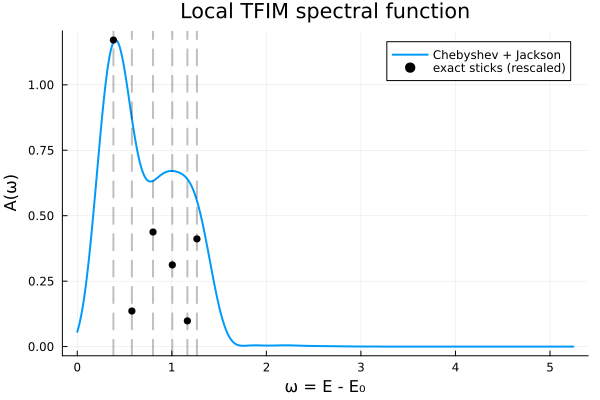

In [4]:
ω_max = min(halfwidth, maximum(excitation_energies) + 0.4)
ω_grid = range(0.0, ω_max; length=700)
ρ_grid = spectrum(collect(ω_grid))

spectrum_plot = plot(
    ω_grid,
    ρ_grid;
    xlabel="ω = E - E₀",
    ylabel="A(ω)",
    label="Chebyshev + Jackson",
    title="Local TFIM spectral function",
)

significant = findall(stick_weights .> 1e-3)
for idx in significant
    vline!(spectrum_plot, [excitation_energies[idx]]; color=:black, alpha=0.25, linestyle=:dash, label="")
end
scatter!(
    spectrum_plot,
    excitation_energies[significant],
    stick_weights[significant] .* maximum(ρ_grid) / maximum(stick_weights[significant]);
    color=:black,
    markersize=4,
    label="exact sticks (rescaled)",
)

spectrum_plot


## Moment diagnostics

The moment sequence is often useful as a numerical diagnostic. Rapidly growing noise or irregular oscillations can indicate that the rescaling is too tight or that the recursion is under-resolved.


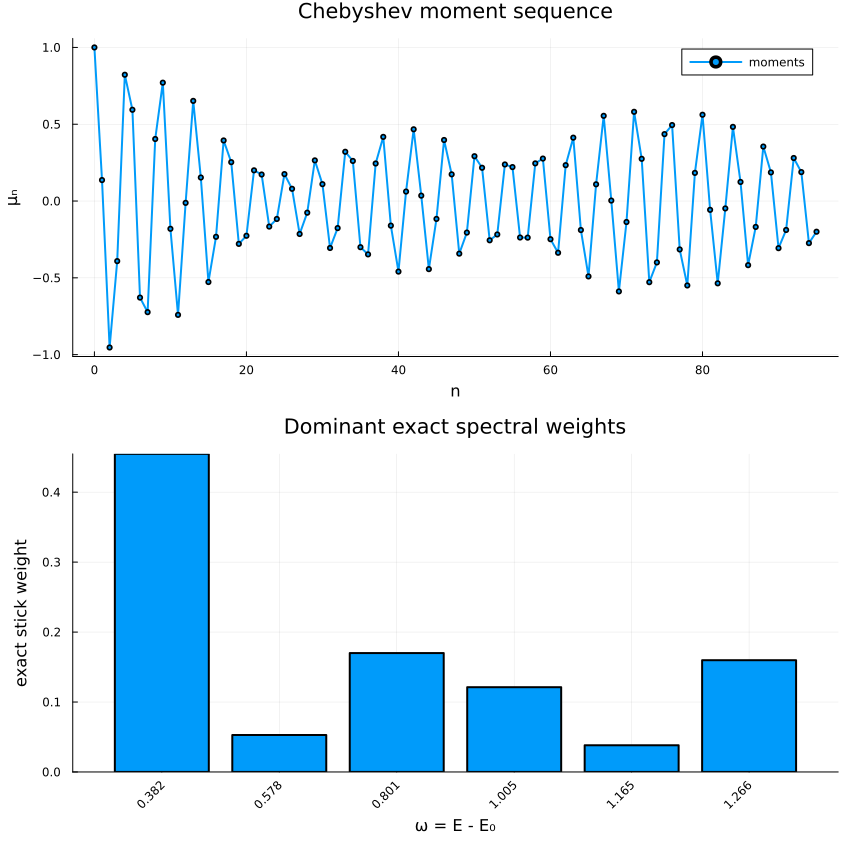

In [5]:
moment_plot = plot(
    0:(order - 1),
    moments;
    xlabel="n",
    ylabel="μₙ",
    marker=:circle,
    markersize=2.5,
    label="moments",
    title="Chebyshev moment sequence",
)

weight_plot = bar(
    string.(round.(excitation_energies[significant]; digits=3)),
    stick_weights[significant];
    xlabel="ω = E - E₀",
    ylabel="exact stick weight",
    label="",
    title="Dominant exact spectral weights",
    xrotation=45,
)

plot(moment_plot, weight_plot; layout=(2, 1), size=(850, 850))
